In [ ]:
!pip install keras-tuner -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 4.5 MB/s eta 0:00:00


Trial 30 Complete [00h 01m 21s]
val_accuracy: 0.9785000085830688

Best val_accuracy So Far: 0.9912499785423279
Total elapsed time: 00h 19m 54s

--- TUNING COMPLETE ---
Optimal Hyperparameters:
  Filters Block 1 : 96
  Filters Block 2 : 256
  Use Block 3     : False
  Dense Units     : 128
  Dropout Rate    : 0.4
  Learning Rate   : 0.0001


Building and training the best model...
Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9274 - loss: 0.2400 - val_accuracy: 0.9811 - val_loss: 0.0656
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9699 - loss: 0.0992 - val_accuracy: 0.9825 - val_loss: 0.0603
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9789 - loss: 0.0709 - val_accuracy: 0.9830 - val_loss: 0.0619
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9833 - loss: 0.0572 - val_accuracy: 0.9876 - val_loss: 0.0459
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9858 - loss: 0.0461 - val_a

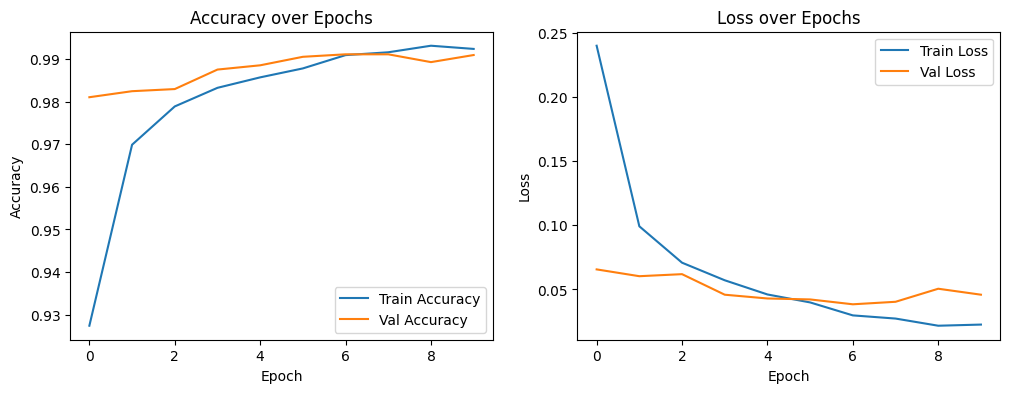

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


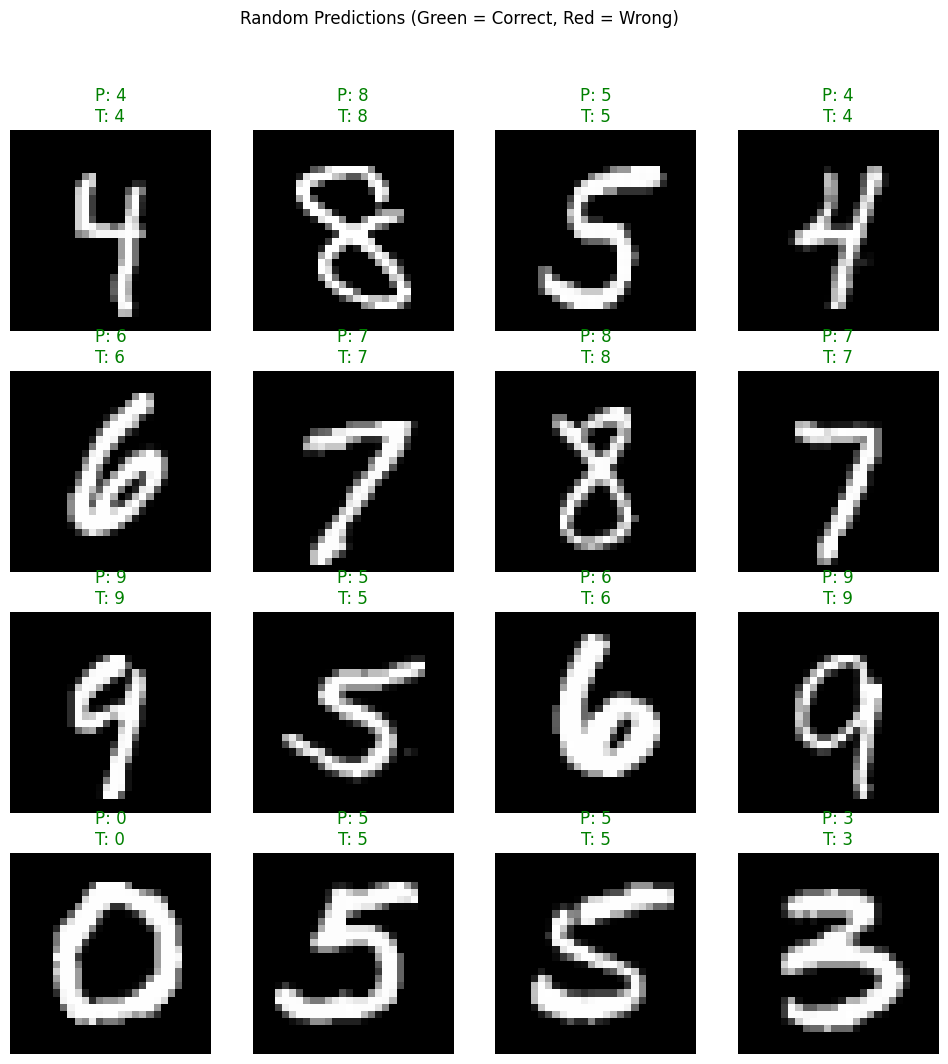

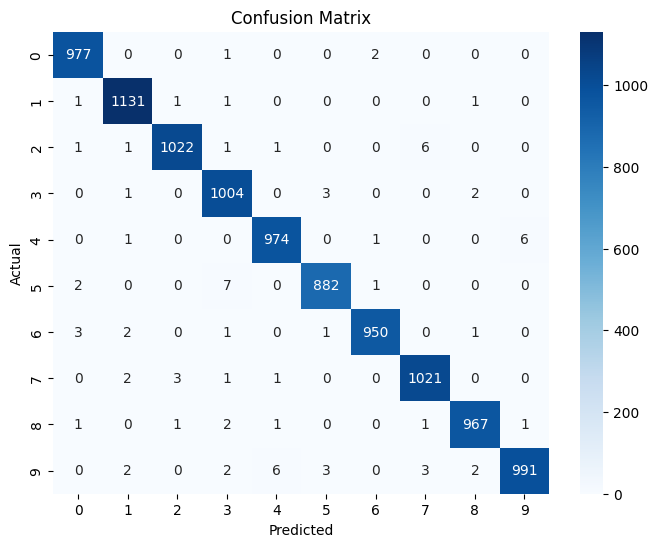

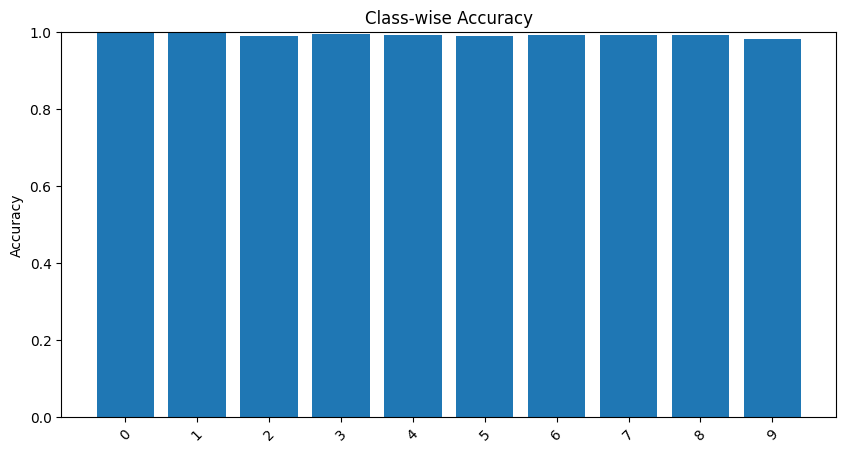

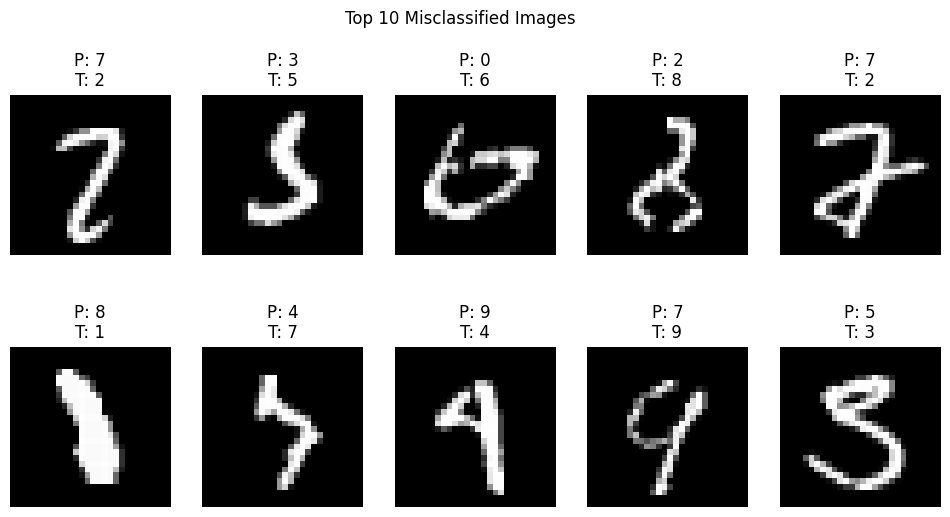

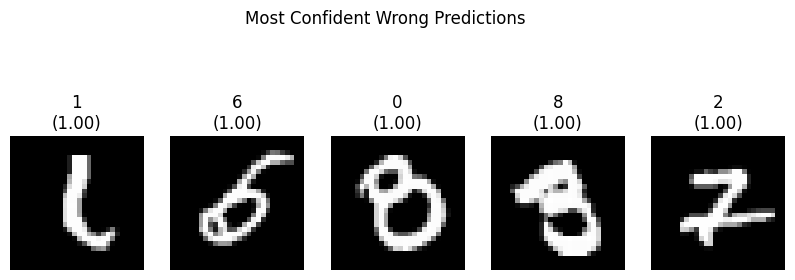

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras_tuner as kt
import matplotlib.pyplot as plt
import numpy as np

# ── 1. LOAD DATASET ──────────────────────────────────────────────────────────
print("Loading MNIST Dataset...")
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# ── 2. PREPROCESS ─────────────────────────────────────────────────────────────
# MNIST is grayscale (28x28x1), reshape to add channel dimension
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32')  / 255.0
x_train = x_train[..., np.newaxis]  # shape: (60000, 28, 28, 1)
x_test  = x_test[..., np.newaxis]   # shape: (10000, 28, 28, 1)

print(f"Training data shape: {x_train.shape}")
print(f"Test data shape:     {x_test.shape}")

# ── 3. CNN MODEL BUILDER FOR KERAS TUNER ──────────────────────────────────────
def build_model(hp):
    model = keras.Sequential()
    model.add(layers.Input(shape=(28, 28, 1)))

    # Block 1
    hp_filters_1 = hp.Int('filters_1', min_value=32, max_value=128, step=32)
    model.add(layers.Conv2D(filters=hp_filters_1, kernel_size=3,
                            activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    # Block 2
    hp_filters_2 = hp.Int('filters_2', min_value=64, max_value=256, step=32)
    model.add(layers.Conv2D(filters=hp_filters_2, kernel_size=3,
                            activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    # Block 3 (optional)
    if hp.Boolean('conv_block_3'):
        hp_filters_3 = hp.Int('filters_3', min_value=64, max_value=256, step=32)
        model.add(layers.Conv2D(filters=hp_filters_3, kernel_size=3,
                                activation='relu', padding='same'))
        model.add(layers.BatchNormalization())

    model.add(layers.Flatten())

    # Dense layer
    hp_units = hp.Int('units', min_value=128, max_value=512, step=64)
    model.add(layers.Dense(units=hp_units, activation='relu'))

    # Dropout
    hp_dropout = hp.Float('dropout', min_value=0.2, max_value=0.5, step=0.1)
    model.add(layers.Dropout(rate=hp_dropout))

    model.add(layers.Dense(10, activation='softmax'))

    # Learning rate
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=hp_learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# ── 4. HYPERPARAMETER TUNING ──────────────────────────────────────────────────
tuner = kt.Hyperband(
    build_model,
    objective='val_accuracy',
    max_epochs=10,
    factor=3,
    directory='my_dir',
    project_name='mnist_cnn_tuning'
)

stop_early = keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)

print("\nStarting Hyperparameter Search...")
tuner.search(x_train, y_train, epochs=10,
             validation_split=0.2, callbacks=[stop_early])

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"""
--- TUNING COMPLETE ---
Optimal Hyperparameters:
  Filters Block 1 : {best_hps.get('filters_1')}
  Filters Block 2 : {best_hps.get('filters_2')}
  Use Block 3     : {best_hps.get('conv_block_3')}
  Dense Units     : {best_hps.get('units')}
  Dropout Rate    : {best_hps.get('dropout')}
  Learning Rate   : {best_hps.get('learning_rate')}
""")

# ── 5. TRAIN BEST MODEL ───────────────────────────────────────────────────────
print("\nBuilding and training the best model...")
model = tuner.hypermodel.build(best_hps)
history = model.fit(x_train, y_train, epochs=20,
                    validation_split=0.2, callbacks=[stop_early])

# ── 6. EVALUATE ───────────────────────────────────────────────────────────────
print("\nEvaluating on Test Set...")
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

# ── 7. ACCURACY & LOSS CURVES ────────────────────────────────────────────────
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'],     label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
plt.show()

# ── 8. RANDOM PREDICTIONS ────────────────────────────────────────────────────
class_names = [str(i) for i in range(10)]  # 0–9 digits

pred_probs  = model.predict(x_test)
pred_labels = np.argmax(pred_probs, axis=1)
true_labels = y_test.flatten()

plt.figure(figsize=(12, 12))
for i in range(16):
    idx = np.random.randint(0, len(x_test))
    plt.subplot(4, 4, i + 1)
    plt.imshow(x_test[idx].squeeze(), cmap='gray')
    color = "green" if pred_labels[idx] == true_labels[idx] else "red"
    plt.title(f"P: {class_names[pred_labels[idx]]}\nT: {class_names[true_labels[idx]]}",
              color=color)
    plt.axis("off")
plt.suptitle("Random Predictions (Green = Correct, Red = Wrong)")
plt.show()

# ── 9. CONFUSION MATRIX ───────────────────────────────────────────────────────
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(true_labels, pred_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ── 10. CLASS-WISE ACCURACY ───────────────────────────────────────────────────
class_accuracy = cm.diagonal() / cm.sum(axis=1)
plt.figure(figsize=(10, 5))
plt.bar(class_names, class_accuracy)
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Class-wise Accuracy")
plt.xticks(rotation=45)
plt.show()

# ── 11. TOP MISCLASSIFIED IMAGES ──────────────────────────────────────────────
misclassified = np.where(pred_labels != true_labels)[0]
plt.figure(figsize=(12, 6))
for i, idx in enumerate(misclassified[:10]):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[idx].squeeze(), cmap='gray')
    plt.title(f"P: {class_names[pred_labels[idx]]}\nT: {class_names[true_labels[idx]]}")
    plt.axis("off")
plt.suptitle("Top 10 Misclassified Images")
plt.show()

# ── 12. MOST CONFIDENT WRONG PREDICTIONS ─────────────────────────────────────
confidence    = np.max(pred_probs, axis=1)
wrong_conf    = confidence[misclassified]
top_wrong     = misclassified[np.argsort(-wrong_conf)[:5]]
plt.figure(figsize=(10, 4))
for i, idx in enumerate(top_wrong):
    plt.subplot(1, 5, i + 1)
    plt.imshow(x_test[idx].squeeze(), cmap='gray')
    plt.title(f"{class_names[pred_labels[idx]]}\n({confidence[idx]:.2f})")
    plt.axis("off")
plt.suptitle("Most Confident Wrong Predictions")
plt.show()